## Import Library

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

## Config

In [2]:
DATASET_DIR = "DatasetBatikFix"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 20
SEED = 42

TRAIN_DIR = os.path.join(DATASET_DIR, "train")
VAL_DIR = os.path.join(DATASET_DIR, "validation")
TEST_DIR = os.path.join(DATASET_DIR, "test")

MODEL_DIR = "experiments/exp_001_baseline"
os.makedirs(MODEL_DIR, exist_ok=True)

## Augmentasi

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.10,
    brightness_range=[0.9, 1.1]
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print(class_names)

Found 2100 images belonging to 20 classes.
Found 600 images belonging to 20 classes.
Found 300 images belonging to 20 classes.
['batik_betawi', 'batik_bokor_kencono', 'batik_buketan', 'batik_dayak', 'batik_jlamprang', 'batik_kawung', 'batik_liong', 'batik_mega_mendung', 'batik_parang', 'batik_sekarjagad', 'batik_sidoluhur', 'batik_sidomukti', 'batik_sidomulyo', 'batik_singa_barong', 'batik_srikaton', 'batik_tribusono', 'batik_tujuh_rupa', 'batik_tuntrum', 'batik_wahyu_tumurun', 'batik_wirasat']


## Build Model

In [4]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,532 (9.25 MB)

 Trainable params: 166,548 (650.58 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Callbacks

In [5]:
callbacks_stage1 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "best_stage1.keras"),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

## Transfer Learning

In [6]:
history_stage1 = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=callbacks_stage1
)

Epoch 1/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.3045 - loss: 2.4702
Epoch 1: val_loss improved from None to 0.60350, saving model to experiments/exp_001_baseline\best_stage1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 222s 3s/step - accuracy: 0.4967 - loss: 1.7503 - val_accuracy: 0.8500 - val_loss: 0.6035 - learning_rate: 0.0010
Epoch 2/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7994 - loss: 0.6789
Epoch 2: val_loss improved from 0.60350 to 0.39759, saving model to experiments/exp_001_baseline\best_stage1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.8067 - loss: 0.6354 - val_accuracy: 0.8883 - val_loss: 0.3976 - learning_rate: 0.0010
Epoch 3/20
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8696 - loss: 0.4581
Epoch 3: val_loss improved from 0.39759 to 0.33697, saving model to experiments/exp_001_baseline\best_stage1.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.8776 - loss: 0.4145 - val_accuracy: 0.9067 - val_loss: 0.3370 - learning_ra

In [7]:
import pandas as pd

df = pd.DataFrame({
    "Epoch": range(1, len(history_stage1.history['accuracy']) + 1),
    "Training Accuracy (%)": [x * 100 for x in history_stage1.history['accuracy']],
    "Training Loss": history_stage1.history['loss'],
    "Validation Accuracy (%)": [x * 100 for x in history_stage1.history['val_accuracy']],
    "Validation Loss": history_stage1.history['val_loss']
})

print(df)

    Epoch  Training Accuracy (%)  Training Loss  Validation Accuracy (%)  \
0       1              49.666667       1.750322                85.000002   
1       2              80.666667       0.635387                88.833332   
2       3              87.761903       0.414470                90.666670   
3       4              90.666670       0.300671                91.833335   
4       5              91.904759       0.267247                92.666668   
5       6              92.666668       0.237493                92.333335   
6       7              93.857145       0.195678                93.166667   
7       8              93.761903       0.188985                93.000001   
8       9              95.428574       0.154022                93.000001   
9      10              96.190476       0.135906                94.000000   
10     11              96.333331       0.129129                94.833332   
11     12              96.285713       0.122686                93.500000   
12     13   

In [8]:
df.to_csv("learning_curve.csv", index=False)

In [9]:
train_loss, train_acc = model.evaluate(
    train_generator, verbose =1
    )
val_loss, val_acc = model.evaluate(
    validation_generator, verbose=1
    )

test_loss, test_acc = model.evaluate(
    test_generator, verbose=1
    )

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print (f"Train Accuracy : {train_acc:.4f}")
print (f"Train Loss : {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.9976 - loss: 0.0162
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 724ms/step - accuracy: 0.9467 - loss: 0.2093
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9567 - loss: 0.1169
Validation Accuracy: 0.9467
Test Accuracy: 0.9567
Train Accuracy : 0.9976
Train Loss : 0.0162
Test Loss: 0.1169
Validation Loss: 0.2093


In [10]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 855ms/step


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

                     precision    recall  f1-score   support

       batik_betawi       0.83      1.00      0.91        15
batik_bokor_kencono       1.00      1.00      1.00        15
      batik_buketan       1.00      1.00      1.00        15
        batik_dayak       1.00      0.73      0.85        15
    batik_jlamprang       0.87      0.87      0.87        15
       batik_kawung       0.92      0.80      0.86        15
        batik_liong       0.88      0.93      0.90        15
 batik_mega_mendung       1.00      1.00      1.00        15
       batik_parang       1.00      1.00      1.00        15
   batik_sekarjagad       1.00      0.93      0.97        15
    batik_sidoluhur       0.93      0.93      0.93        15
    batik_sidomukti       1.00      1.00      1.00        15
    batik_sidomulyo       0.94      1.00      0.97        15
 batik_singa_barong       1.00      1.00      1.00        15
     batik_srikaton       1.00      1.00      1.00        15
    batik_tribusono    

In [12]:
from sklearn.metrics import classification_report
import pandas as pd

# buat classification report dalam bentuk dictionary
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

# ubah menjadi DataFrame
df_report = pd.DataFrame(report).transpose()

# simpan ke CSV
df_report.to_csv("classification_report_batik.csv")

print("Classification report berhasil disimpan ke classification_report_batik.csv")

Classification report berhasil disimpan ke classification_report_batik.csv


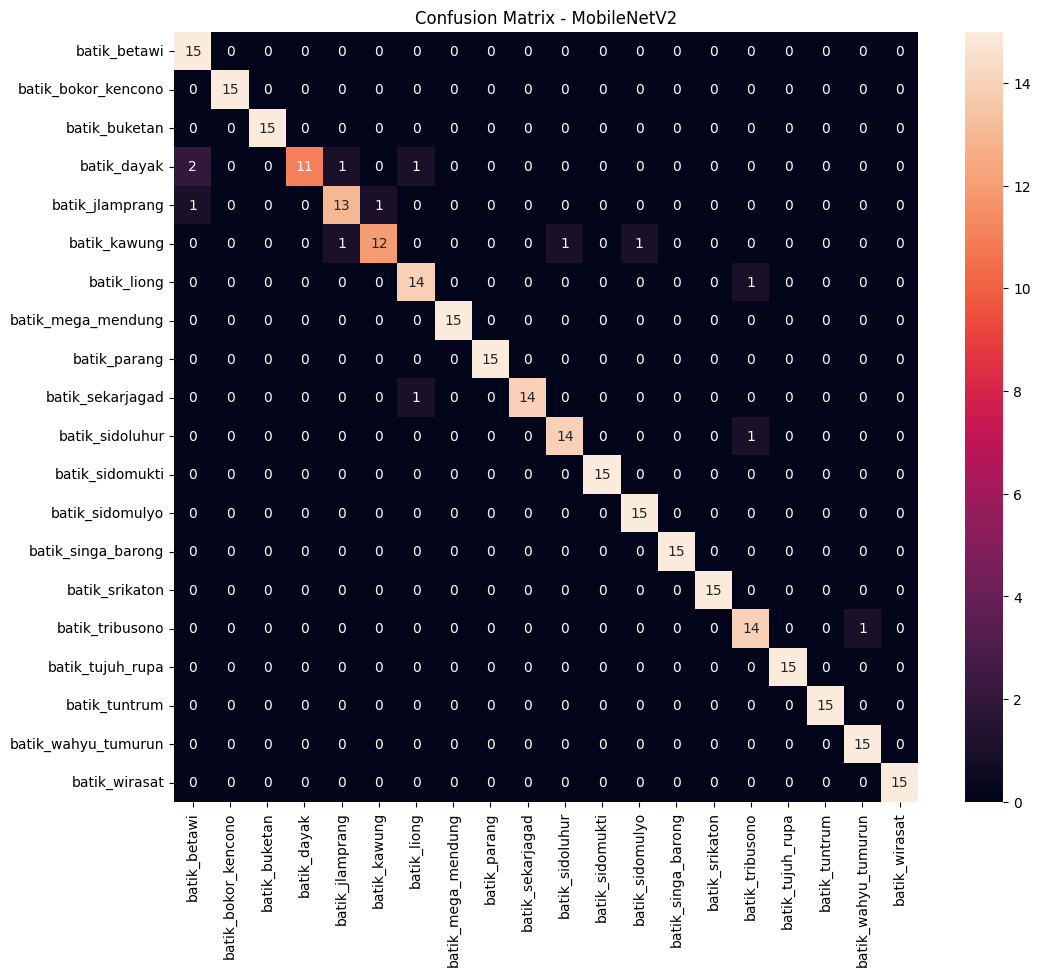

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

In [14]:
model.save(os.path.join(MODEL_DIR, "mobilenetv2_batik_exp001.keras"))
print("Model saved.")

Model saved.


## Fine Tuning Stage

In [16]:
base_model.trainable = True

fine_tune_at = 130

for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    # Freeze BatchNorm
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
callbacks_stage2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=os.path.join(MODEL_DIR, "best_stage2.keras"),
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

history_stage2 = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=15, 
        callbacks=callbacks_stage2
    )

Epoch 1/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9717 - loss: 0.0859
Epoch 1: val_loss improved from None to 0.22734, saving model to experiments/exp_001_baseline\best_stage2.keras
66/66 ━━━━━━━━━━━━━━━━━━━━ 122s 2s/step - accuracy: 0.9781 - loss: 0.0726 - val_accuracy: 0.9483 - val_loss: 0.2273 - learning_rate: 1.0000e-05
Epoch 2/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9805 - loss: 0.0639
Epoch 2: val_loss did not improve from 0.22734
66/66 ━━━━━━━━━━━━━━━━━━━━ 114s 2s/step - accuracy: 0.9800 - loss: 0.0671 - val_accuracy: 0.9467 - val_loss: 0.2384 - learning_rate: 1.0000e-05
Epoch 3/15
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9824 - loss: 0.0530
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.

Epoch 3: val_loss did not improve from 0.22734
66/66 ━━━━━━━━━━━━━━━━━━━━ 111s 2s/step - accuracy: 0.9829 - loss: 0.0568 - val_accuracy: 0.9450 - val_loss: 0.2368 - learning_rate: 1.0000e-05
Epoch 4/15
66/66 ━━━━━━━━━━━━━━━━━━━

In [17]:
import pandas as pd

df = pd.DataFrame({
    "Epoch": range(1, len(history_stage2.history['accuracy']) + 1),
    "Training Accuracy (%)": [x * 100 for x in history_stage2.history['accuracy']],
    "Training Loss": history_stage2.history['loss'],
    "Validation Accuracy (%)": [x * 100 for x in history_stage2.history['val_accuracy']],
    "Validation Loss": history_stage2.history['val_loss']
})

print(df)

    Epoch  Training Accuracy (%)  Training Loss  Validation Accuracy (%)  \
0       1              97.809523       0.072631                94.833332   
1       2              98.000002       0.067071                94.666666   
2       3              98.285717       0.056800                94.499999   
3       4              98.285717       0.052453                95.333332   
4       5              98.476189       0.046824                94.833332   
5       6              98.333335       0.051231                95.166665   
6       7              98.285717       0.050118                95.166665   
7       8              98.761904       0.042279                95.499998   
8       9              99.142855       0.030690                95.666665   
9      10              98.904765       0.039445                95.666665   
10     11              98.904765       0.038027                95.333332   
11     12              98.809522       0.036831                95.333332   
12     13   

In [18]:
df.to_csv("finetuninglearning.csv", index=False)

## Evaluation

In [19]:
train_loss, train_acc = model.evaluate(
    train_generator, verbose =1
    )
val_loss, val_acc = model.evaluate(
    validation_generator, verbose=1
    )

test_loss, test_acc = model.evaluate(
    test_generator, verbose=1
    )

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print (f"Train Accuracy : {train_acc:.4f}")
print (f"Train Loss : {train_loss:.4f}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9976 - loss: 0.0079
19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 754ms/step - accuracy: 0.9567 - loss: 0.2087
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 774ms/step - accuracy: 0.9700 - loss: 0.1033
Validation Accuracy: 0.9567
Test Accuracy: 0.9700
Train Accuracy : 0.9976
Train Loss : 0.0079
Test Loss: 0.1033
Validation Loss: 0.2087


In [20]:
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

10/10 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step 


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes, target_names=class_names))

                     precision    recall  f1-score   support

       batik_betawi       0.88      1.00      0.94        15
batik_bokor_kencono       1.00      1.00      1.00        15
      batik_buketan       1.00      1.00      1.00        15
        batik_dayak       1.00      0.87      0.93        15
    batik_jlamprang       0.88      0.93      0.90        15
       batik_kawung       0.92      0.80      0.86        15
        batik_liong       1.00      0.93      0.97        15
 batik_mega_mendung       1.00      1.00      1.00        15
       batik_parang       1.00      1.00      1.00        15
   batik_sekarjagad       1.00      0.93      0.97        15
    batik_sidoluhur       0.93      0.93      0.93        15
    batik_sidomukti       1.00      1.00      1.00        15
    batik_sidomulyo       0.94      1.00      0.97        15
 batik_singa_barong       1.00      1.00      1.00        15
     batik_srikaton       1.00      1.00      1.00        15
    batik_tribusono    

In [22]:
from sklearn.metrics import classification_report
import pandas as pd

# buat classification report dalam bentuk dictionary
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names,
    output_dict=True
)

# ubah menjadi DataFrame
df_report = pd.DataFrame(report).transpose()

# simpan ke CSV
df_report.to_csv("classification_report_batik_finetuning.csv")

print("Classification report berhasil disimpan ke classification_report_batik_finetuning.csv")

Classification report berhasil disimpan ke classification_report_batik_finetuning.csv


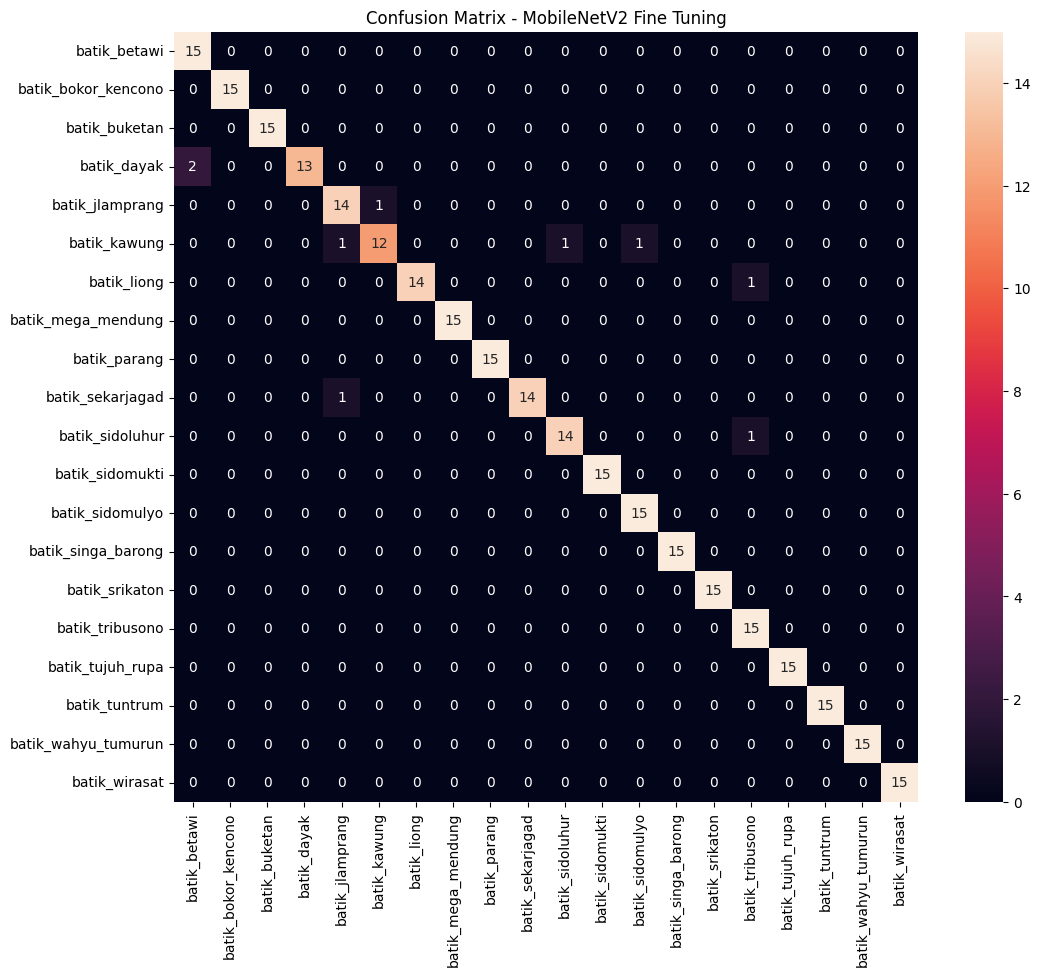

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix - MobileNetV2 Fine Tuningx")
plt.show()

In [25]:
model.save(os.path.join(MODEL_DIR, "mobilenet_Finetuning.keras"))
print("Model saved.")

Model saved.


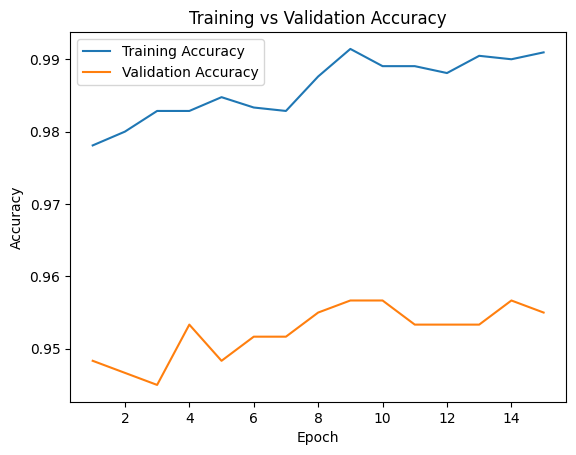

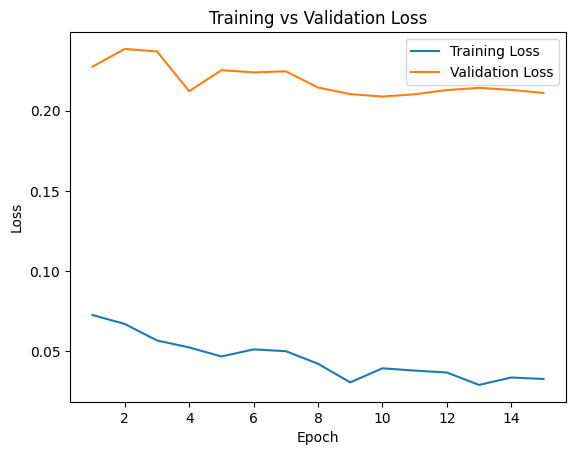

In [26]:
import matplotlib.pyplot as plt

acc = history_stage2.history['accuracy']
val_acc = history_stage2.history['val_accuracy']

loss = history_stage2.history['loss']
val_loss = history_stage2.history['val_loss']

epochs = range(1, len(acc) + 1)

# Grafik Accuracy
plt.figure()
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

# Grafik Loss
plt.figure()
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()